In [1]:
import tensorflow as tf

In [7]:
first_model = tf.keras.models.load_model('../models/first_model.keras')

In [12]:
import sys, os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

import numpy as np
import matplotlib.pyplot as plt
from data_processing import MelDataManager

data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()


Loaded cached data from ../../data/processed/melspec_cache.npz


In [10]:
labels = mgr.one_hot()
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(14975, 10))

In [11]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step


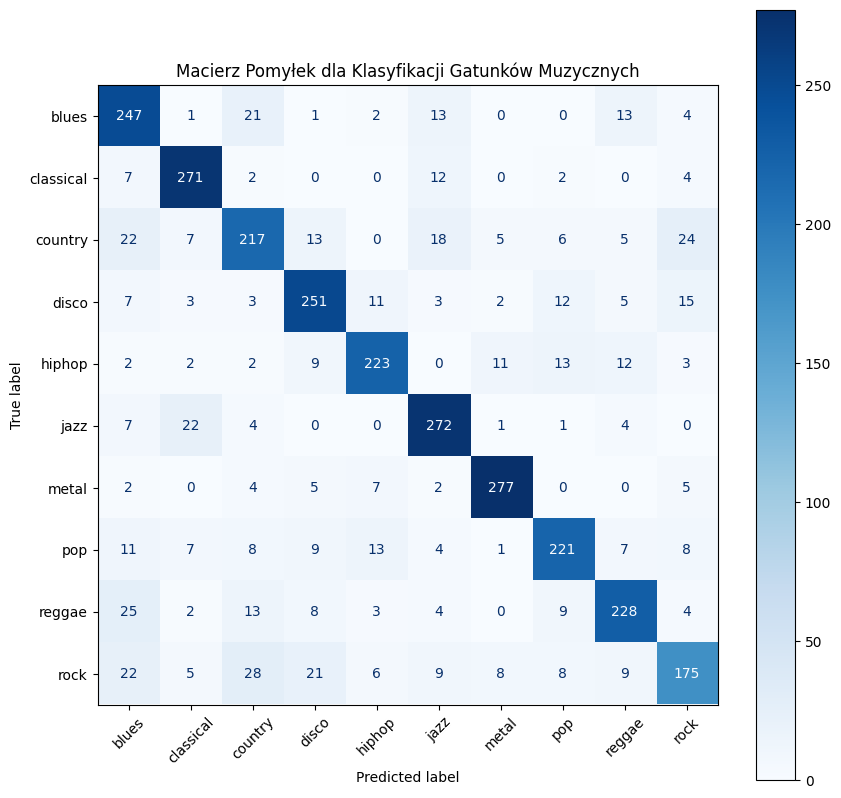

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
Y_pred_proba = first_model.predict(X_test)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10)) # Ustaw większy rozmiar
cm_display.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Macierz Pomyłek dla Klasyfikacji Gatunków Muzycznych')
plt.xticks(rotation=45) # Obróć etykiety X, aby były czytelne
plt.show()